# Sound Classification between horn and no-horn using CNNs

## Load all the data first from memory

In [2]:
import numpy as np
import pandas as pd
import librosa as lr
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset_dir = 'env/dataset/Dataset/'
df_train = pd.read_csv('env/dataset/hornbase_train.csv')
df_test = pd.read_csv('env/dataset/hornbase_test.csv')

df_train['path'] = dataset_dir + df_train['file']
df_test['path'] = dataset_dir + df_test['file']

df_train['audio'] = df_train['path'].apply(lambda a: lr.load(a))
df_test['audio'] = df_test['path'].apply(lambda a: lr.load(a))

In [48]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   file          324 non-null    str   
 1   class         324 non-null    str   
 2   class number  324 non-null    int64 
 3   path          324 non-null    str   
 4   audio         324 non-null    object
dtypes: int64(1), object(1), str(3)
memory usage: 12.8+ KB


In [49]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   file          756 non-null    str   
 1   class         756 non-null    str   
 2   class number  756 non-null    int64 
 3   path          756 non-null    str   
 4   audio         756 non-null    object
dtypes: int64(1), object(1), str(3)
memory usage: 29.7+ KB


## Compute the spectogram for the CNN

In [53]:
stft = lr.stft(df_train.loc[5, 'audio'][0], n_fft=512, hop_length=256)

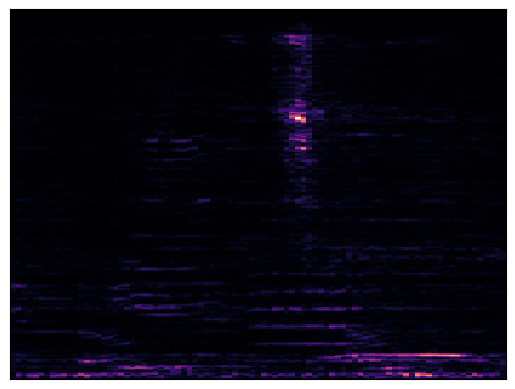

In [54]:
lr.display.specshow(np.abs(stft))

In [85]:
mel_spec = lr.feature.melspectrogram(y = df_train.loc[6, 'audio'][0], sr= df_train.loc[5, 'audio'][1], n_mels=256, hop_length=256).T

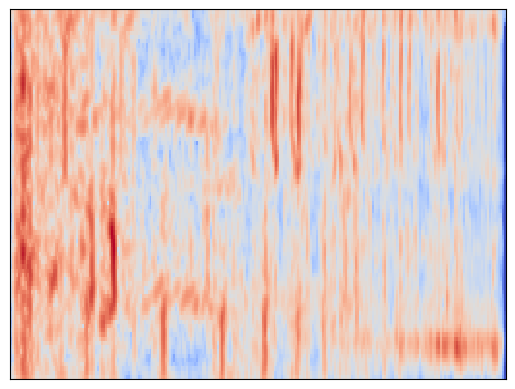

In [86]:
lr.display.specshow(lr.power_to_db(mel_spec), sr=df_train.loc[5, 'audio'][1])

In [87]:
mel_spec.shape

(87, 256)

In [9]:
df_train['mel_spectogram'] = [lr.feature.melspectrogram(y = audio[0], sr = audio[1], n_mels=256, hop_length=256).T for audio in df_train['audio']]

In [10]:
df_test['mel_spectogram'] = [lr.feature.melspectrogram(y = audio[0], sr = audio[1], n_mels=256, hop_length=256).T for audio in df_test['audio']]

In [92]:
df_train.loc[0, 'mel_spectogram'].shape

(87, 256)

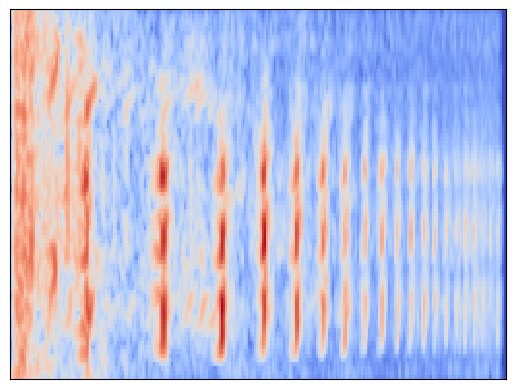

In [94]:
lr.display.specshow(lr.power_to_db(df_train.loc[10, 'mel_spectogram']), sr=df_train.loc[10, 'audio'][1])

In [95]:
stft = lr.stft(df_train.loc[10, 'audio'][0], n_fft=512, hop_length=256)

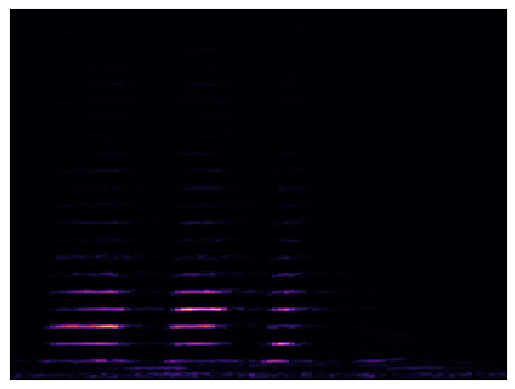

In [96]:
lr.display.specshow(np.abs(stft))

## Classify the whole thing using the training data

In [97]:
%pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.3 MB/s eta 0:00:000m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 12.8 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 3.0 MB/s eta 0:00:00m eta 0:00:010:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 7.7 MB/s eta 0:00:00m eta 0:00:010:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 13.0 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 17.6 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.4/121.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━

In [5]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

I0000 00:00:1778661018.048017    8950 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778661020.367999    8950 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778661028.320592    8950 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
model = models.Sequential()

# Input layer
model.add(layers.Input((87, 256, 1)))

# First ReLU Layer
model.add(layers.Conv2D(8, (3, 3), padding='same', activation='relu'))
model.add(layers.MaxPool2D())

# Second ReLU layer
model.add(layers.Conv2D(8, (3, 3), padding='same', activation='relu'))
model.add(layers.MaxPool2D())

model.add(layers.Flatten())
model.add(layers.Dense(32, activation="relu"))
model.add(layers.Dense(2, activation="softmax"))

E0000 00:00:1778236596.742562   27368 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
model.compile('sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 87, 256, 8)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 43, 128, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 43, 128, 8)     │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 21, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       344,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 344,826 (1.32 MB)

 Trainable params: 344,826 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [148]:
history = model.fit(np.stack(df_train['mel_spectogram']), df_train['class number'], epochs=124, verbose=1)

Epoch 1/124


W0000 00:00:1778234701.032645   19507 cpu_allocator_impl.cc:82] Allocation of 67350528 exceeds 10% of free system memory.


24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 314ms/step - accuracy: 0.8823 - loss: 0.3123
Epoch 2/124
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 307ms/step - accuracy: 0.9087 - loss: 0.2407
Epoch 3/124
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 291ms/step - accuracy: 0.9074 - loss: 0.2196
Epoch 4/124
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 276ms/step - accuracy: 0.9167 - loss: 0.2070
Epoch 5/124
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 300ms/step - accuracy: 0.9286 - loss: 0.1975
Epoch 6/124
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.9233 - loss: 0.1904
Epoch 7/124
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 282ms/step - accuracy: 0.9312 - loss: 0.1821
Epoch 8/124
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 273ms/step - accuracy: 0.9365 - loss: 0.1754
Epoch 9/124
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 270ms/step - accuracy: 0.9392 - loss: 0.1710
Epoch 10/124
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 266ms/step - accuracy: 0.9365 - loss: 0.1676
Epoch 11/124
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 271ms/step - accuracy: 0.7738 - loss: 1.1320
Epoch 12/124
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 341ms/s

In [135]:
history

In [149]:
model.save('my_model.keras')

In [150]:
model.evaluate(np.stack(df_test['mel_spectogram']), df_test['class number'])

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.7901 - loss: 0.9869


[0.9869042634963989, 0.790123462677002]

In [151]:
predictions = model.predict(np.stack(df_test['mel_spectogram']))
predicted_cats = predictions.argmax(axis=-1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step


In [152]:
predicted_cats

array([0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,

In [153]:
(predicted_cats == df_test['class number']).mean()

np.float64(0.7901234567901234)

<Axes: >

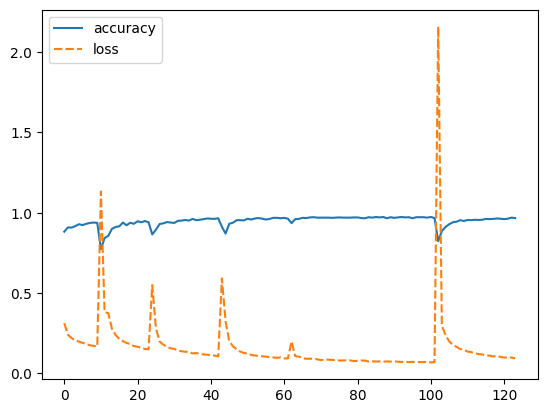

In [157]:
sns.lineplot(history.history)

In [6]:
ldmod = models.load_model('my_model.keras')

E0000 00:00:1778661031.291176    8950 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
ldmod

<Sequential name=sequential_2, built=True>

## Predictive power goes to 80% aproximately to detect horn vs no horn

In [11]:
preds = ldmod.predict(np.stack(df_train['mel_spectogram']))

W0000 00:00:1778661292.584501    8950 cpu_allocator_impl.cc:82] Allocation of 67350528 exceeds 10% of free system memory.
W0000 00:00:1778661293.144290   16257 cpu_allocator_impl.cc:82] Allocation of 22806528 exceeds 10% of free system memory.


 2/24 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step 

W0000 00:00:1778661293.406685   16257 cpu_allocator_impl.cc:82] Allocation of 22806528 exceeds 10% of free system memory.
W0000 00:00:1778661293.537204   16256 cpu_allocator_impl.cc:82] Allocation of 22806528 exceeds 10% of free system memory.


 4/24 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step

W0000 00:00:1778661293.666087   16258 cpu_allocator_impl.cc:82] Allocation of 22806528 exceeds 10% of free system memory.


24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step


<Axes: >

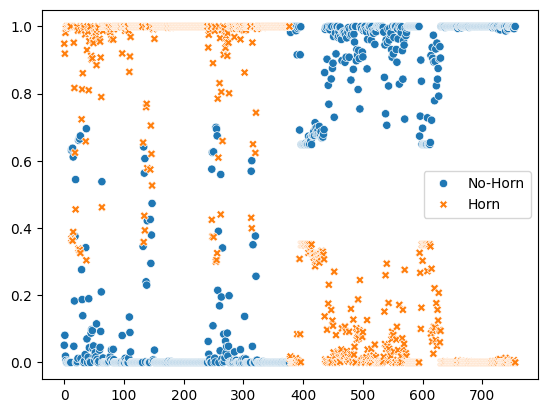

In [12]:
sns.scatterplot(pd.DataFrame(preds, columns=['No-Horn', 'Horn']))

Text(0.5, 1.0, 'Divergence from correctness')

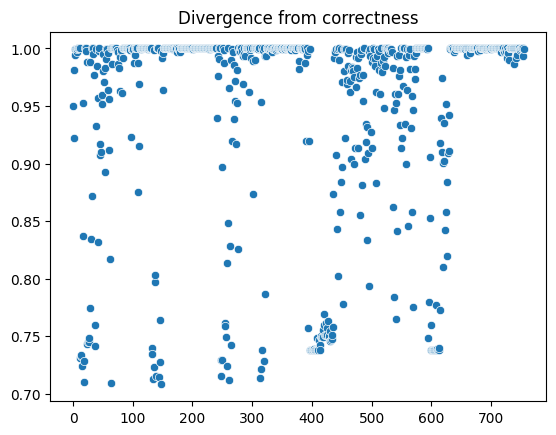

In [13]:
sns.scatterplot(np.sqrt(preds.T[0] ** 2 + preds.T[1] ** 2))
plt.title('Divergence from correctness')